# Task 1: Exploratory Data Analysis
#### Environment Setup and Data Loading


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np

In [2]:
# Loading a subset to ensure the kernel stays stable
df = pd.read_csv('../data/raw/newsData/raw_analyst_ratings.csv', nrows=100000)

In [6]:
# Remove the unnecessary index column
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])
df.head()

,headline,url,publisher,date,stock
0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


### 2: Descriptive Statistics (Headline Lengths)


#### 2.1 Headline Length Analysis
Calculating the character count for each headline to understand the typical length of news titles.

In [3]:
# Create a new column for the number of characters in each headline
df['headline_len'] = df['headline'].str.len()

In [4]:
# Descriptive statistics for the textual lengths
print(df['headline_len'].describe())

count    100000.000000
mean         73.639590
std          40.465787
min           7.000000
25%          47.000000
50%          65.000000
75%          88.000000
max         458.000000
Name: headline_len, dtype: float64


### 2.2 Visualizing Length Distribution
A histogram to show how headline lengths are distributed across the dataset.

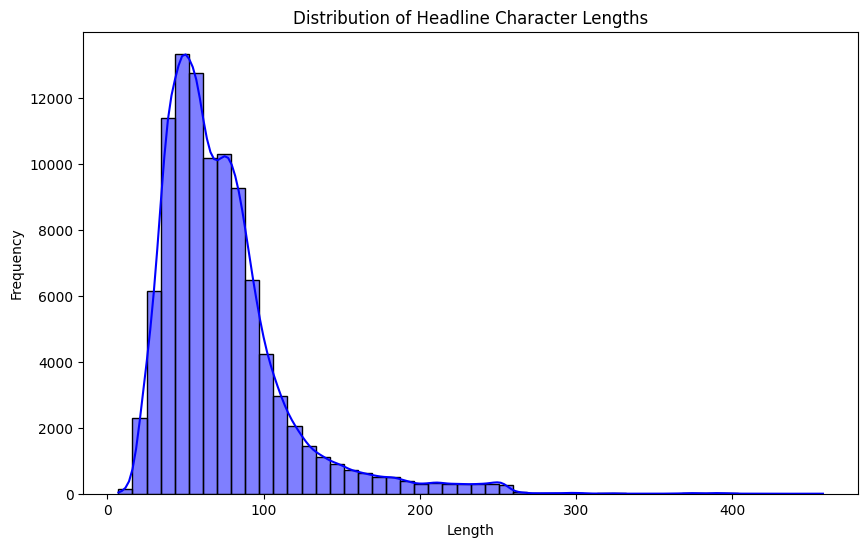

In [5]:
# Visualization of headline character count distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['headline_len'], bins=50, kde=True, color='blue')
plt.title('Distribution of Headline Character Lengths')
plt.xlabel('Length')
plt.ylabel('Frequency')
plt.show()

## Section 3: Publisher Analysis
#### 3.1 Publisher Cleaning
Extracting domains from email addresses used as publisher names to group organizations correctly.

In [6]:
# Function to clean publisher names and extract domains from emails
def extract_domain(name):
    if '@' in str(name):
        return name.split('@')[-1]
    return name

df['publisher_clean'] = df['publisher'].apply(extract_domain)

#### 3.2 Identifying Top Publishers
Ranking the top 10 most active news sources.

In [7]:
# Identify the most active publishers
top_publishers = df['publisher_clean'].value_counts().head(10)
print(top_publishers)

publisher_clean
Paul Quintaro        16791
Lisa Levin           14137
Benzinga Newsdesk    10856
Charles Gross         6523
Monica Gerson         6181
Eddie Staley          4256
Hal Lindon            3706
Benzinga Staff        2368
Juan Lopez            2130
Vick Meyer            2130
Name: count, dtype: int64


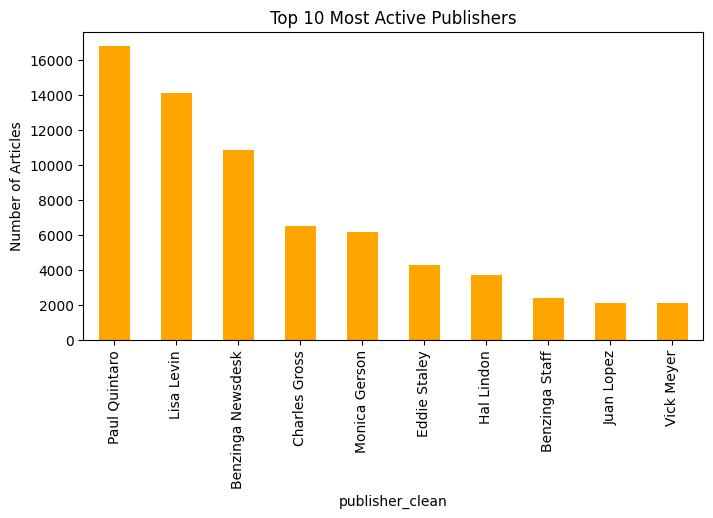

In [20]:
# Visualization of publisher activity
plt.figure(figsize=(8, 4))
top_publishers.plot(kind='bar', color='orange')
plt.title('Top 10 Most Active Publishers')
plt.ylabel('Number of Articles')
plt.show()

## Section 4: Time Series Analysis
#### 4.1 Daily Publication Trends
Analyzing how the volume of news changes day-to-day to identify spikes.

In [8]:
# Convert date column to datetime objects
df['date'] = pd.to_datetime(df['date'], errors='coerce', utc=True)

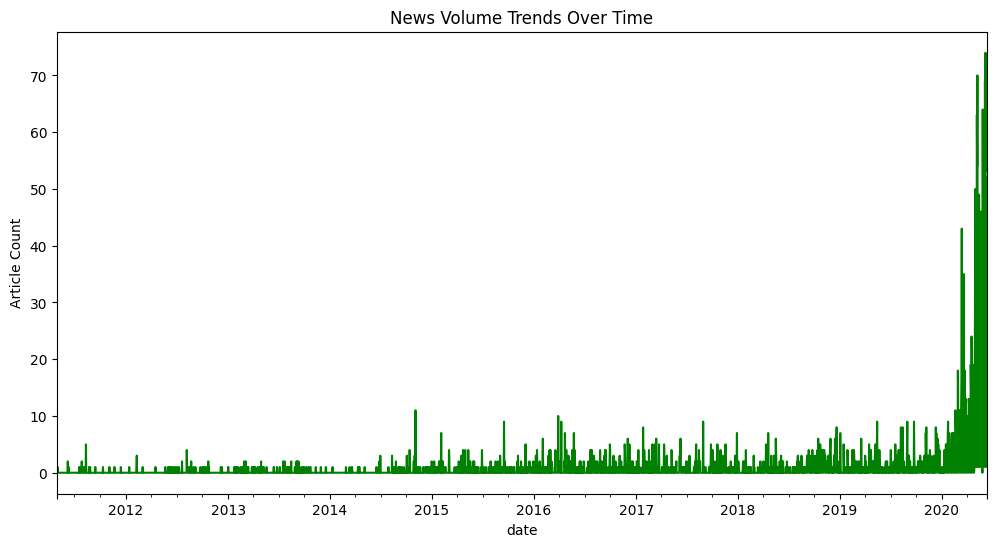

In [14]:
# Aggregate news volume by day
daily_news = df.resample('D', on='date').size()

plt.figure(figsize=(12, 6))
daily_news.plot(color='green')
plt.title('News Volume Trends Over Time')
plt.ylabel('Article Count')
plt.show()

#### 4.2 Hourly Publication Patterns
Identifying the peak hours for news releases (Time of Day analysis).

C:\Users\HP\AppData\Local\Temp\ipykernel_24648\1195872147.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=hourly_activity.index, y=hourly_activity.values, palette='viridis')


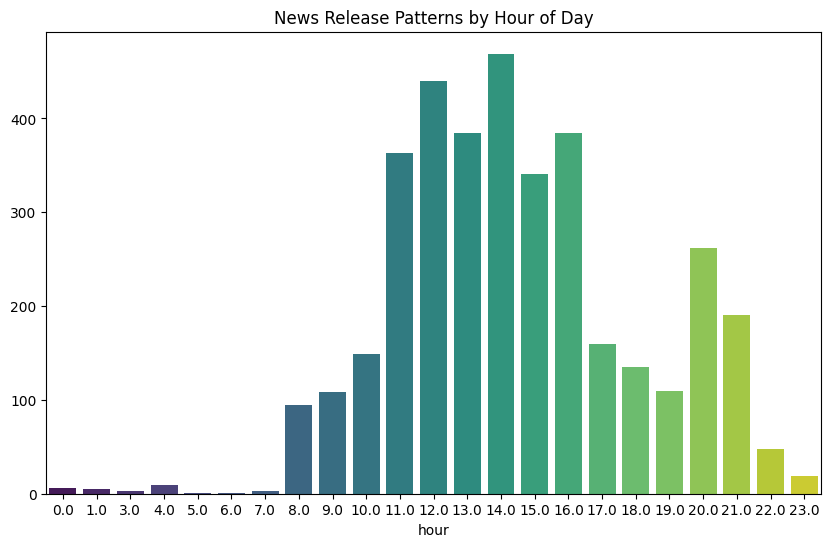

In [9]:
# Extract hour of day to find release patterns
df['hour'] = df['date'].dt.hour
hourly_activity = df['hour'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
sns.barplot(x=hourly_activity.index, y=hourly_activity.values, palette='viridis')
plt.title('News Release Patterns by Hour of Day')
plt.show()

## Section 5: Text Analysis (Topic Modeling)
#### 5.1 Keyword Extraction
Using NLP techniques (CountVectorizer) to find common 2-word phrases like "earnings beat".

In [10]:
# Use CountVectorizer to find the most common 2-word phrases
vectorizer = CountVectorizer(stop_words='english', ngram_range=(2, 2), max_features=20)
X = vectorizer.fit_transform(df['headline'].dropna())

#### 5.2 Processing Text Results
Turning the matrix results back into a readable DataFrame for visualization.

In [11]:
# Convert the keyword results into a readable list
words = vectorizer.get_feature_names_out()
counts = X.toarray().sum(axis=0)
words_df = pd.DataFrame({'Phrase': words, 'Count': counts}).sort_values(by='Count', ascending=False)

#### 5.3 Visualizing Common Themes
A bar chart showing the top 20 recurring themes in the news.

C:\Users\HP\AppData\Local\Temp\ipykernel_24648\4003704551.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=words_df, x='Count', y='Phrase', palette='magma')


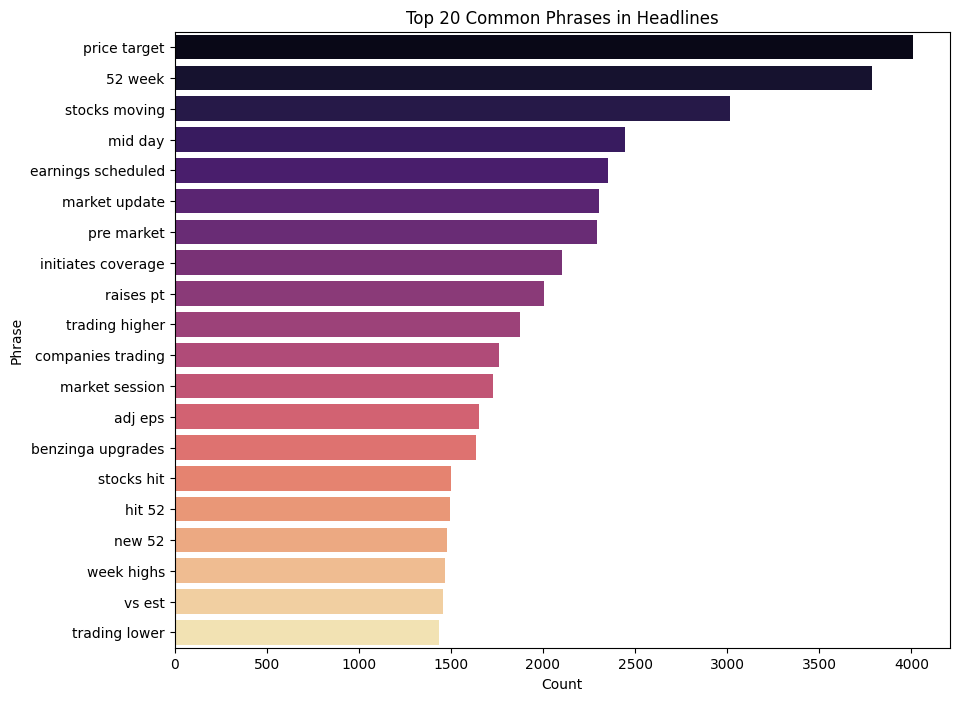

In [12]:
# Visualize recurring themes like "earnings beat" or "price target"
plt.figure(figsize=(10, 8))
sns.barplot(data=words_df, x='Count', y='Phrase', palette='magma')
plt.title('Top 20 Common Phrases in Headlines')
plt.show()